# Lecture 2 — Model Answer
## Bar Charts: World Happiness Report 2023



---


In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Dataset: World Happiness Report 2023
# Real dataset: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023
# Place the downloaded CSV at: data/world_happiness_2023.csv
df = pd.read_csv('../data/world_happiness_2023.csv')

# Rename columns for convenience
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']
print(f"{len(df)} countries loaded")
print(df.head())


63 countries loaded
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


---
## Main Task — Model Answer

**Story:** Western Europe sits in a league of its own — more than 1.5 points above the nearest region. Sub-Saharan Africa and South Asia trail by over 2.5 points.


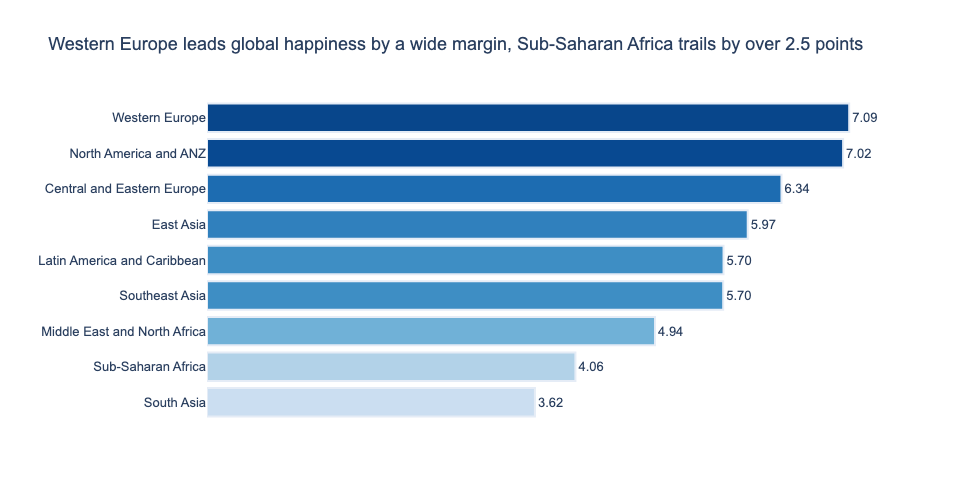

In [12]:
# ── DESIGN DECISIONS ────────────────────────────────────────────────
# 1. Horizontal orientation: region names are long (Rule 3)
# 2. Sorted ascending so happiest region sits at top (Rule 2)
# 3. xaxis range=[0, 8.2] enforces zero baseline (Rule 1)
# 4. Sequential colour scale (Blues) reinforces the ranking — these are
#    ordered values, not distinct categories, so a gradient is appropriate
# 5. Value labels outside bars replace the x-axis tick labels (cleaner)
# 6. Insight title names the outlier and the direction
# ────────────────────────────────────────────────────────────────────

region_avg = df.groupby('Region')['Happiness_Score'].mean().reset_index().sort_values('Happiness_Score')

fig = px.bar(
    data_frame=region_avg,
    x='Happiness_Score', y='Region', orientation='h',
    color='Happiness_Score', color_continuous_scale='Blues', 
    range_color=[2.5, 7.5], # controls min and max depth of color on the color gradient
    text=region_avg['Happiness_Score'].round(2), # text over or inside the bars
    title='Western Europe leads global happiness by a wide margin, Sub-Saharan Africa trails by over 2.5 points',
    labels={'Happiness_Score': '', 'Region': ''}
)

fig.update_traces(
    texttemplate='%{text:.2f}', 
    textposition='outside', # controls where the text on the bars is positioned
    marker_line_width=2 # changes the border width
)

fig.update_layout(
    xaxis=dict(showticklabels=False, showgrid=False),
    yaxis=dict(gridcolor='white'),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    coloraxis_showscale=False,
    height=500
)
fig.show()

---
## Extension — Model Answer


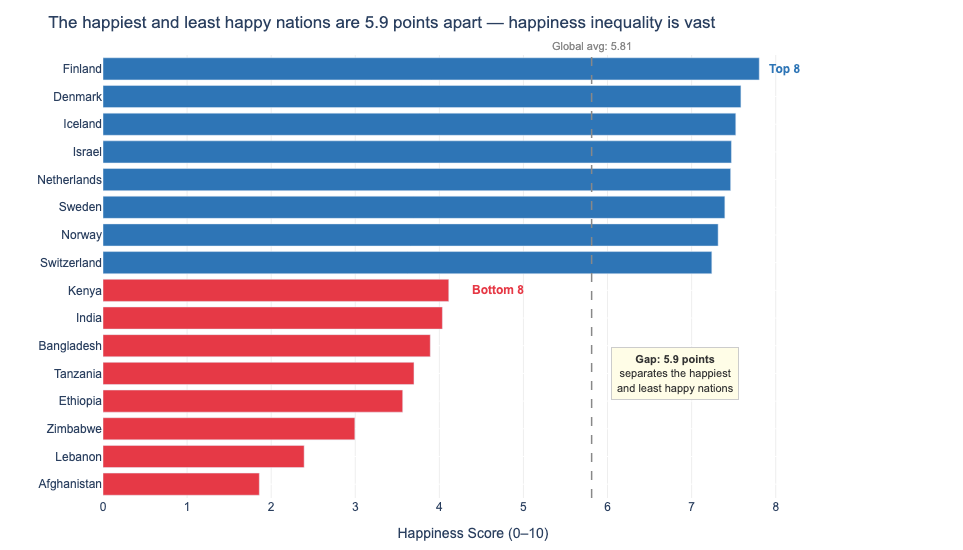

In [31]:
# prep data
top8 = df.nlargest(8,'Happiness_Score').assign(Group='Top 8')
bottom8 = df.nsmallest(8,'Happiness_Score').assign(Group='Bottom 8')
combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score').reset_index(drop=True)
global_avg = df['Happiness_Score'].mean()

# set colors for the top and bottom groups
colors = ['#2E75B6' if g == 'Top 8' else '#E63946' for g in combined['Group']]



fig = px.bar(
    data_frame=combined,
    x='Happiness_Score', y='Country',
    orientation='h',
    color='Group',
    color_discrete_map={'Top 8': '#2E75B6', 'Bottom 8': '#E63946'},
    hover_data={'Region': True, 'Happiness_Score': ':.2f', 'Group': False},
    custom_data=combined
)

# controls the tooltip text using html and the custom data passed above in px.bar
fig.update_traces(
    hovertemplate='<b>%{y}</b><br>Score: %{x:.2f}<br>%{customdata[0]}<extra></extra>'
)

# adding the average vertical line
fig.add_vline(x=global_avg, line_dash='dash', line_color='#888888', line_width=1.5,
              annotation_text=f'Global avg: {global_avg:.2f}',
              annotation_position='top', annotation_font=dict(size=11, color='#888888'))


# adding the text highlighting the gap, top and bottom numbers
# Notes: 1. Global average reference line gives a meaningful anchor — without it
#           7.8 and 1.9 are just numbers; the average shows both are extremes
#.       2. Gap annotation makes the story concrete — the audience doesn't have
#           to compute 7.8 - 1.9 themselves

gap = top8['Happiness_Score'].max() - bottom8['Happiness_Score'].min()
fig.add_annotation(
    x=6.8, y=4,
    text=f'<b>Gap: {gap:.1f} points</b><br>separates the happiest<br>and least happy nations',
    showarrow=False, font=dict(size=11, color='#333333', family='Arial'),
    bgcolor='#FFFDE7', bordercolor='#CCCCCC', borderwidth=1, borderpad=5
)
fig.add_annotation(x=8.1, y=15, text='<b>Top 8</b>',
                   showarrow=False, font=dict(color='#2E75B6', size=12))
fig.add_annotation(x=4.7, y=7, text='<b>Bottom 8</b>',
                   showarrow=False, font=dict(color='#E63946', size=12))

fig.update_layout(
    title=f'The happiest and least happy nations are {gap:.1f} points apart — happiness inequality is vast',
    xaxis=dict(range=[0, 8.8], gridcolor='#EEEEEE', title='Happiness Score (0–10)'),
    yaxis=dict(gridcolor='white', title=''),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    showlegend=False,
    margin=dict(l=30, r=120, t=55, b=40),
    height=550
)
fig.show()
